<a href="https://colab.research.google.com/github/badhandp07-netizen/Pixels-to-Parcels/blob/main/Assignment_1_Deeksha_Badhan_250316.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**PART 1- NUMPY FUNDAMENTALS**

In [ ]:
import numpy as np
# Create a 1D array of 100 evenly spaced values between 0 and 20
arr=np.linspace(0,20,100)

mean=np.mean(arr)
median=np.median(arr)
std_dev=np.std(arr)
variance= np.var(arr)

print("Mean:",mean)
print("Median:",median)
print("Standard Deviation:",std_dev)
print("Variance:",variance)

Mean: 10.0
Median: 10.0
Standard Deviation: 5.831529302570125
Variance: 34.00673400673401


In [ ]:
array=np.linspace(1,36,36)
print(array)
narray=array.reshape(4,9)
print(narray)
nwarr=narray.reshape(-1)
print(nwarr)



[ 1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11. 12. 13. 14. 15. 16. 17. 18.
 19. 20. 21. 22. 23. 24. 25. 26. 27. 28. 29. 30. 31. 32. 33. 34. 35. 36.]
[[ 1.  2.  3.  4.  5.  6.  7.  8.  9.]
 [10. 11. 12. 13. 14. 15. 16. 17. 18.]
 [19. 20. 21. 22. 23. 24. 25. 26. 27.]
 [28. 29. 30. 31. 32. 33. 34. 35. 36.]]
[ 1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11. 12. 13. 14. 15. 16. 17. 18.
 19. 20. 21. 22. 23. 24. 25. 26. 27. 28. 29. 30. 31. 32. 33. 34. 35. 36.]


**PART 2- PANDAS AND DATA WRANGLING**

In [ ]:
import pandas as pd
import seaborn as sns
df=sns.load_dataset('titanic')
# Display first 5 rows
print("First 5 Rows:")
print(df.head())

print("\nDataset information:")
df.info()

print("\nDescriptive Statistics:")
print(df.describe())




First 5 Rows:
   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -

In [ ]:
import seaborn as sns
import pandas as pd
titanic = sns.load_dataset('titanic')
# Missing value count and percentage
missing = pd.DataFrame({
    'Missing Count': titanic.isnull().sum(),
    'Percentage Missing': (titanic.isnull().sum() / len(titanic)) * 100
})
#Use of isnull().sum()
#Checks every cell in the dataset.
#Returns True if a value is missing.adds all True values column-wise.

# Show only columns with missing values
missing = missing[missing['Missing Count'] > 0]
print(missing)

# Fill age using median age within each passenger class
titanic['age'] = titanic.groupby('pclass')['age'].transform(lambda x: x.fillna(x.median())
)

# Find mode
embarked_mode = titanic['embarked'].mode()[0]

# Fill missing values
titanic['embarked'] = titanic['embarked'].fillna(embarked_mode)

#The deck column has 688 missing values out of 891 records.The column therefore provides limited reliable information and is better removed from the analysis.


print("Missing values in age:", titanic['age'].isnull().sum())
print("Missing values in embarked:", titanic['embarked'].isnull().sum())






             Missing Count  Percentage Missing
age                    177           19.865320
embarked                 2            0.224467
deck                   688           77.216611
embark_town              2            0.224467
Missing values in age: 0
Missing values in embarked: 0


**PART 3- MATPLOTLIB VISUALISATIONS**

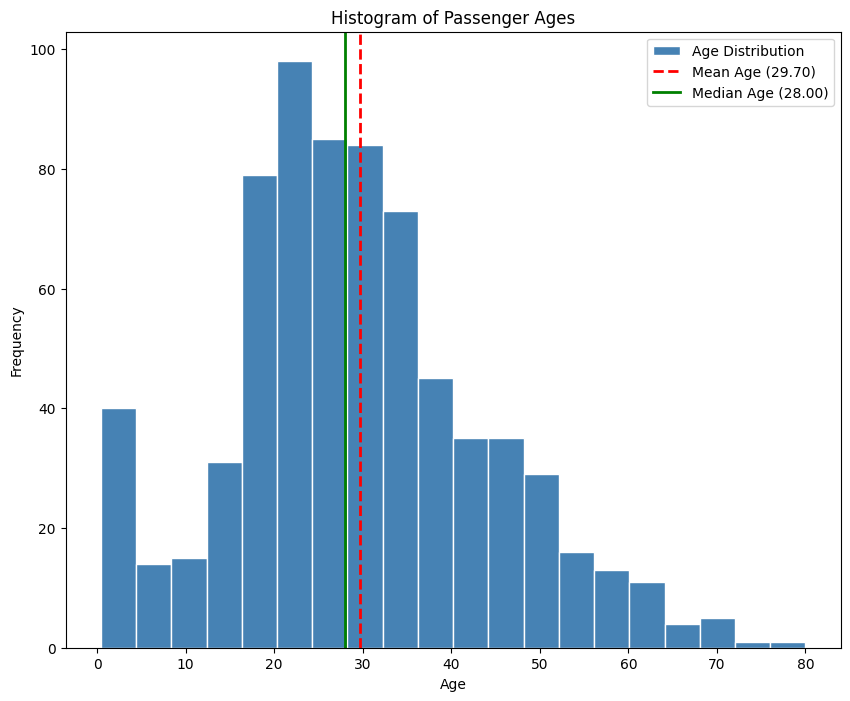

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Load Titanic dataset
titanic = sns.load_dataset('titanic')

# Remove missing age values for plotting
ages = titanic['age'].dropna()

# Calculate mean and median
mean_age = ages.mean()
median_age = ages.median()

# Create histogram
plt.figure(figsize=(10, 8))

plt.hist(
    ages,
    bins=20,
    color='steelblue',
    edgecolor='white',
    label='Age Distribution'
)

# Mean line
plt.axvline(
    mean_age,
    color='red',
    linestyle='--',
    linewidth=3,
    label=f'Mean Age ({mean_age:.2f})'
)

# Median line
plt.axvline(
    median_age,
    color='green',
    linewidth=2,
    label=f'Median Age ({median_age:.2f})'
)

# Title and labels
plt.title('Histogram of Passenger Ages')
plt.xlabel('Age')
plt.ylabel('Frequency')

# Legend
plt.legend()

plt.show()




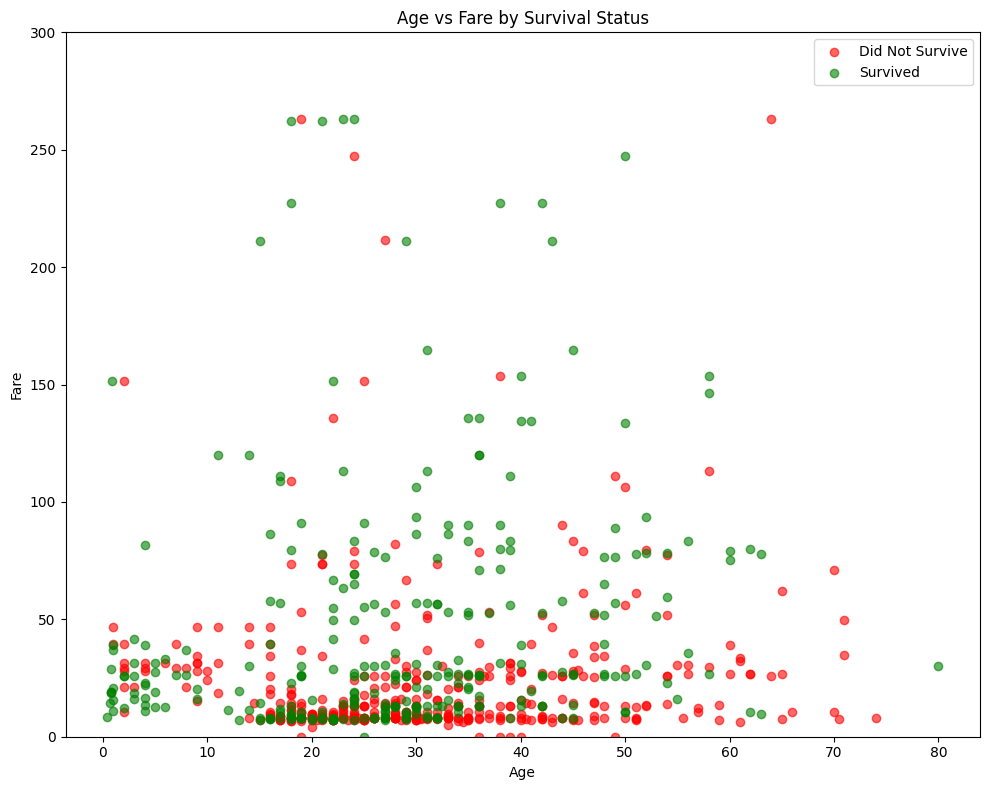

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Load Titanic dataset
titanic = sns.load_dataset('titanic')

# Remove rows with missing age or fare
data = titanic[['age', 'fare', 'survived']].dropna()

# Separate survivors and non-survivors
survived = data[data['survived'] == 1]
not_survived = data[data['survived'] == 0]

# Create figure
plt.figure(figsize=(10, 8))

# Scatter plot for non-survivors
plt.scatter(
    not_survived['age'],
    not_survived['fare'],
    color='red',
    alpha=0.6,
    label='Did Not Survive'
)

# Scatter plot for survivors
plt.scatter(
    survived['age'],
    survived['fare'],
    color='green',
    alpha=0.6,
    label='Survived'
)

# Set y-axis limit
plt.ylim(0, 300)
#The Titanic dataset contains a few passengers with extremely high fares.To improve readability, the y-axis has been capped at 300 using: plt.ylim(0, 300)

# Title and labels
plt.title('Age vs Fare by Survival Status')
plt.xlabel('Age')
plt.ylabel('Fare')

# Legend
plt.legend()

# Adjust spacing
plt.tight_layout()

# Display plot
plt.show()



**Part 4 — Exploratory Data Analysis**

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
# Load dataset
df = pd.read_csv("advertising[1].csv")

# Shape
print("Shape of dataset:", df.shape)

# Data types
print("\nData Types:")
print(df.dtypes)

# Missing values
print("\nMissing Values:")
print(df.isnull().sum())

# Descriptive statistics
print("\nDescriptive Statistics:")
print(df.describe())

Shape of dataset: (200, 4)

Data Types:
TV           float64
Radio        float64
Newspaper    float64
Sales        float64
dtype: object

Missing Values:
TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64

Descriptive Statistics:
               TV       Radio   Newspaper       Sales
count  200.000000  200.000000  200.000000  200.000000
mean   147.042500   23.264000   30.554000   15.130500
std     85.854236   14.846809   21.778621    5.283892
min      0.700000    0.000000    0.300000    1.600000
25%     74.375000    9.975000   12.750000   11.000000
50%    149.750000   22.900000   25.750000   16.000000
75%    218.825000   36.525000   45.100000   19.050000
max    296.400000   49.600000  114.000000   27.000000


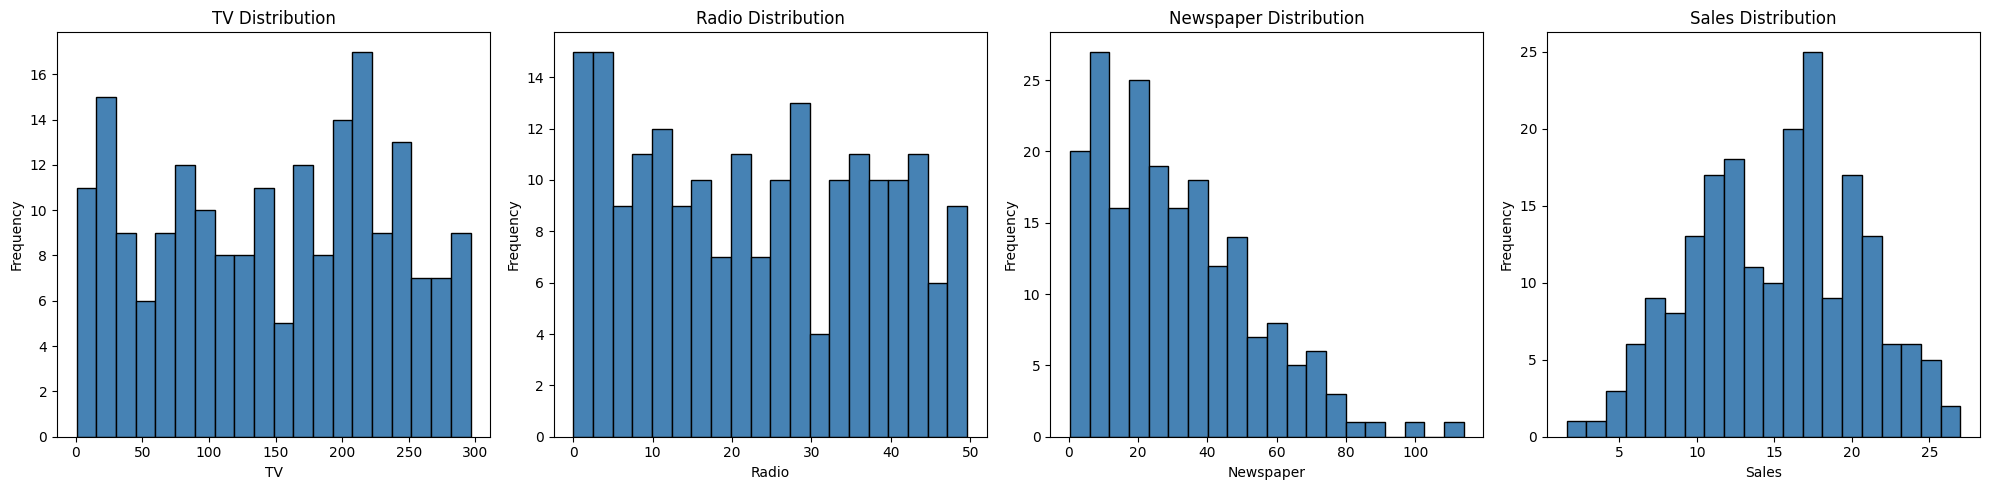

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
columns = ['TV', 'Radio', 'Newspaper', 'Sales']

# Create histogram for each column
for i, col in enumerate(columns):

    axes[i].hist(
        df[col],
        bins=20,
        color='steelblue',
        edgecolor='black'
    )

    axes[i].set_title(f'{col} Distribution')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')


plt.tight_layout()
plt.show()

#OUTLIERS : Newspaper variable is the only variable that shows clear signs of potential outliers due to its long right tail and a few unusually large values. The TV, Radio, and Sales variables appear relatively well-behaved, with no obvious extreme observations.

                 TV     Radio  Newspaper     Sales
TV         1.000000  0.054809   0.056648  0.901208
Radio      0.054809  1.000000   0.354104  0.349631
Newspaper  0.056648  0.354104   1.000000  0.157960
Sales      0.901208  0.349631   0.157960  1.000000


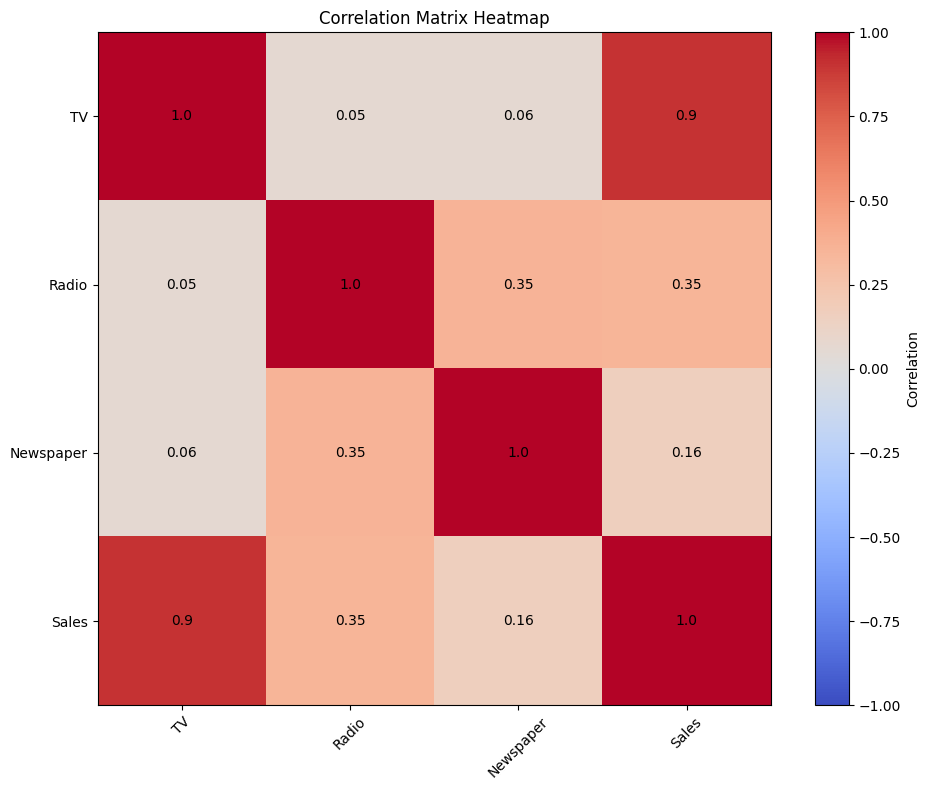

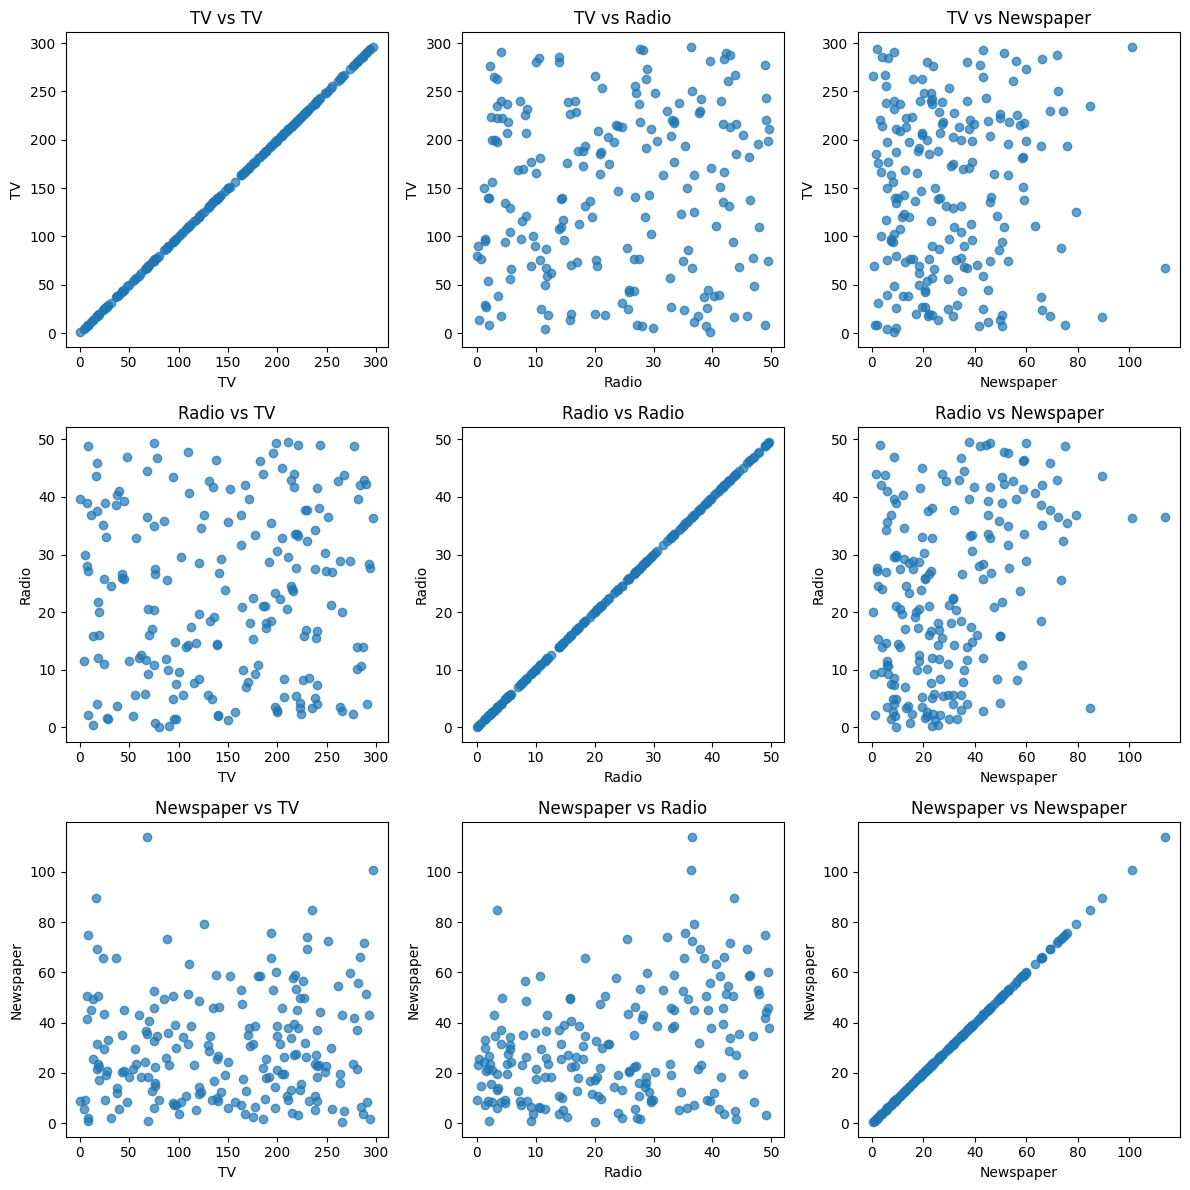

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
# Load dataset
df = pd.read_csv("advertising[1].csv")
corr_matrix = df.corr()
print(corr_matrix)

plt.figure(figsize=(10,8))

# Heatmap
plt.imshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1)

# Color bar
plt.colorbar(label='Correlation')

# Tick labels
plt.xticks(
    range(len(corr_matrix.columns)),
    corr_matrix.columns,
    rotation=45
)

plt.yticks(
    range(len(corr_matrix.columns)),
    corr_matrix.columns
)

# Annotate each cell
for i in range(len(corr_matrix)):
    for j in range(len(corr_matrix.columns)):
        plt.text(
            j,
            i,
            round(corr_matrix.iloc[i, j], 2),
            ha='center',
            va='center',
            color='black'
        )
plt.title('Correlation Matrix Heatmap')

plt.tight_layout()
plt.show()


#The TV advertising budget has the highest positive correlation with Sales.This indicates a strong positive relationship: As TV advertising expenditure increases, Sales tend to increase as well.TV and Radio advertising expenditures have a very weak correlation.
#There is essentially no linear relationship between TV and Radio spending.

variables = ['TV', 'Radio', 'Newspaper']

fig, axes = plt.subplots(3, 3, figsize=(12, 12))

for i in range(3):
    for j in range(3):

        axes[i, j].scatter(
            df[variables[j]],
            df[variables[i]],
            alpha=0.7
        )

        axes[i, j].set_title(
            f'{variables[i]} vs {variables[j]}'
              )

        axes[i, j].set_xlabel(
            variables[j]
        )

        axes[i, j].set_ylabel(
            variables[i]
             )

plt.tight_layout()
plt.show()

**Part 5 — Linear Regression**

In [ ]:
import pandas as pd
import numpy as np

# Load dataset
df = pd.read_csv('advertising[1].csv')
# Feature (X) and target (y)
X = df['TV'].values
y = df['Sales'].values

# Training data
X_train = X[:160]
y_train = y[:160]

# Testing data
X_test = X[160:]
y_test = y[160:]

x_bar = np.mean(X_train)
y_bar = np.mean(y_train)
numerator = np.sum((X_train - x_bar) * (y_train - y_bar))

denominator = np.sum((X_train - x_bar) ** 2)

m = numerator / denominator
b = y_bar - m * x_bar
print("Slope (m):", m)
print("Intercept (b):", b)
y_pred = m * X_test + b

mse = np.mean((y_test - y_pred) ** 2)

print("Mean Squared Error:", mse)

Slope (m): 0.05572601895005874
Intercept (b): 6.993686960994353
Mean Squared Error: 5.459799471482253


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv('Mall_Customers.csv')

# Display first 5 rows
print("First 5 Rows:")
print(df.head())

# Dataset information
print("\nDataset Info:")
print(df.info())

# Descriptive statistics
print("\nDescriptive Statistics:")
print(df.describe())


plt.figure(figsize=(8,6))

plt.scatter(
    df['Annual Income (k$)'],
    df['Spending Score (1-100)']
)

plt.title('Annual Income vs Spending Score')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')

plt.tight_layout()
plt.show()

First 5 Rows:
   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB
None

Descriptive Statistic

### Visual Inspection of Annual Income vs Spending Score

The scatter plot reveals several distinct clusters of customers rather than one continuous distribution.

Some visible groups include:

1. Low Income, Low Spending
   - Customers with low income and low spending scores.

2. Low Income, High Spending
   - Customers with relatively low income but high spending scores.

3. High Income, Low Spending
   - Customers who earn a lot but spend relatively little.

4. High Income, High Spending
   - Customers with both high income and high spending scores.

5. Average Income, Average Spending
   - Customers concentrated near the center of the plot.

Based on visual inspection, approximately 5 clusters appear to exist in the data.

This is one reason why K-Means clustering with k = 5 is commonly used on this dataset and often produces meaningful customer segments.

In [ ]:
from sklearn.cluster import KMeans
import pandas as pd

# Features used for clustering
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

# Fit K-Means
kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

df['Cluster'] = kmeans.fit_predict(X)

centroids = pd.DataFrame(
    kmeans.cluster_centers_,
    columns=['Annual Income (k$)', 'Spending Score (1-100)']
)

centroids.index.name = "Cluster"

print("Cluster Centroids")
print(centroids.round(2))

for cluster in sorted(df['Cluster'].unique()):

    cluster_data = df[df['Cluster'] == cluster]

    print(f"\nCluster {cluster}")
    print("-" * 30)

    print("Customer Count:",
          len(cluster_data))

    print("Mean Annual Income:",
          round(cluster_data['Annual Income (k$)'].mean(), 2))

    print("Mean Spending Score:",
          round(cluster_data['Spending Score (1-100)'].mean(), 2))

**Part 7 — Neural Networks on MNIST**

In [ ]:
from tensorflow.keras.datasets import mnist
import matplotlib.pyplot as plt
import numpy as np

# Load dataset
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# Print shapes
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

# Normalize pixel values
X_train = X_train / 255.0
X_test = X_test / 255.0

# Create 5x5 grid
fig, axes = plt.subplots(5, 5, figsize=(8, 8))

# Random image selection
random_indices = np.random.choice(
    len(X_train),
    25,
    replace=False
)

# Display images
for ax, idx in zip(axes.flat, random_indices):

    ax.imshow(X_train[idx], cmap='gray')

    ax.set_title(
        f"Label: {y_train[idx]}",
        fontsize=10
    )

    ax.axis('off')

plt.tight_layout()
plt.show()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
X_train shape: (60000, 28, 28)
y_train shape: (60000,)
X_test shape: (10000, 28, 28)
y_test shape: (10000,)


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense
import matplotlib.pyplot as plt

# Build model
model = Sequential([
    Flatten(input_shape=(28,28)),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

# Compile
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Summary
model.summary()

# Train
history = model.fit(
    X_train,
    y_train,
    epochs=15,
    validation_split=0.2
)

# Accuracy Plot
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'],
         label='Training Accuracy')
plt.plot(history.history['val_accuracy'],
         label='Validation Accuracy')

plt.title('Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout()
plt.show()

# Loss Plot
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'],
         label='Training Loss')
plt.plot(history.history['val_loss'],
         label='Validation Loss')

plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

# Evaluate
test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test,
    verbose=0

  )

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

# Predictions
y_prob = model.predict(X_test)
y_pred = y_prob.argmax(axis=1)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

# Heatmap
plt.figure(figsize=(8,6))

plt.imshow(cm, cmap='Blues')
plt.colorbar(label='Count')

plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')

plt.xticks(np.arange(10))
plt.yticks(np.arange(10))

for i in range(10):
    for j in range(10):

        plt.text(
            j,
            i,
            str(cm[i,j]),
             ha='center',
            va='center'
        )

plt.tight_layout()
plt.show()

# Misclassified images
misclassified = np.where(
    y_pred != y_test
)[0]

fig, axes = plt.subplots(1,3,figsize=(10,4))

for ax, idx in zip(
    axes,
    misclassified[:3]
    ):

    ax.imshow(
        X_test[idx],
        cmap='gray'
    )

    ax.set_title(
        f"True: {y_test[idx]}\nPred: {y_pred[idx]}"
    )

    ax.axis('off')

plt.tight_layout()
plt.show()


):

    ax.imshow(
        X_test[idx],
        cmap='gray'
    )

    ax.set_title(
        f"True: {y_test[idx]}\nPred: {y_pred[idx]}"
    )

    ax.axis('off')

plt.tight_layout()
plt.show()
Markdown Answer
Which two digits are most commonly confused with each other?

The exact answer depends on your confusion matrix, but in MNIST a fully connected neural network commonly confuses:

4 and 9
3 and 5
5 and 8
7 and 9

Among these, 4 and 9 are often one of the most frequent confusion pairs because handwritten versions can have very similar shapes.

Why might they be confused?
Handwriting styles vary significantly between people.
Some digits are visually similar when written quickly.
Poorly centered or faint digits can lose distinguishing features.
A simple feedforward network only sees pixel values and may struggle with subtle shape differences compared to more advanced models such as CNNs.
Example Misclassified Images

The three images displayed above show:

The true label.
The model's predicted label.

By inspecting these examples, you can often see that the digit is ambiguous even to a human observer, which explains why the model made an incorrect prediction.

In [ ]:
# Add channel dimension
X_train_cnn = X_train.reshape(
    -1, 28, 28, 1
)

X_test_cnn = X_test.reshape(
    -1, 28, 28, 1
)

print(X_train_cnn.shape)
print(X_test_cnn.shape)

# Add channel dimension
X_train_cnn = X_train.reshape(
    -1, 28, 28, 1
)

X_test_cnn = X_test.reshape(
    -1, 28, 28, 1
)

print(X_train_cnn.shape)
print(X_test_cnn.shape)

cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_model.summary()

cnn_history = cnn_model.fit(
    X_train_cnn,
    y_train,
    epochs=10,
    validation_split=0.2
)

cnn_test_loss, cnn_test_acc = cnn_model.evaluate(
    X_test_cnn,
    y_test,
    verbose=0
)

print("CNN Test Accuracy:",
      cnn_test_acc)

print("CNN Test Loss:",
      cnn_test_loss)


cnn_train_acc = cnn_history.history[
    'accuracy'
][-1]

cnn_val_acc = cnn_history.history[
    'val_accuracy'
][-1]

import pandas as pd

comparison = pd.DataFrame({

    'Model': [
        'Feedforward NN',
        'CNN'
    ],

    'Parameters': [
        109386,
        225034
    ],

    'Train Acc': [
        round(ff_train_acc,4),
        round(cnn_train_acc,4)
    ],

    'Val Acc': [
        round(ff_val_acc,4),
        round(cnn_val_acc,4)
    ],

    'Test Acc': [
        round(test_accuracy,4),
        round(cnn_test_acc,4)
    ],

    'Epochs': [
        15,
        10
    ]
})

print(comparison)

CNNs preserve the spatial structure of an image, allowing them to learn local patterns such as edges, corners, curves, and textures. Convolutional layers examine small neighboring regions of pixels, so they can recognize meaningful visual features regardless of where they appear in the image. In contrast, a dense network first flattens the image into a 1D vector, losing information about the relationships between nearby pixels. As a result, CNNs are much more effective at capturing visual patterns and typically achieve higher accuracy on image classification tasks.